# Target A/B 모델링 — 향상된 피처(100개) 기준 최종본

기존 78개 피처에 다음 두 가지를 추가한 `X_enhanced_features.csv`(100개 피처)로 재학습합니다.
- **기관 타겟 인코딩** (`org_target_enc_A`, `org_target_enc_B`): 기관별 과거 평균 성과 (K-fold로 누수 없이 계산)
- **텍스트 SVD 20개** (`text_svd_0~19`): 제목·혜택·우대사항·추가혜택 텍스트를 문자 n-gram TF-IDF → SVD로 압축

Target A는 LightGBM·Ridge·(팀원이 발견한) 앙상블 블렌딩까지 비교하고,
Target B는 LightGBM·Ridge·RandomForest·앙상블 블렌딩까지 비교합니다.

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

## 1. 데이터 로드 및 분할

In [3]:
# X_enhanced_features.csv: activity_id + 100개 피처 (78개 기존 + 기관인코딩 2개 + 텍스트SVD 20개)
X_enh = pd.read_csv("../crawl_data/Final_datasets.csv")

# 타겟은 X_model.csv에서 activity_id로 가져옴
xm = pd.read_csv("../crawl_data/checkpoint/X_model.csv")
y_full = xm.set_index("activity_id").loc[X_enh["activity_id"], ["daily_views_log1p", "scrap_rate (%)"]].reset_index(drop=True)

X_feat = X_enh.drop(columns=["activity_id"])

# 80:20 분할 (seed 42로 재현 가능)
X_train, X_test, y_train, y_test = train_test_split(X_feat, y_full, test_size=0.2, random_state=RANDOM_STATE)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (5811, 100) | X_test: (1453, 100)


## 2. 결측치 처리

`activity_period_months`(활동기간, 160건 결측)는 LightGBM은 자체 처리 가능하지만
Ridge·RandomForest는 NaN을 못 받으므로, **train 중앙값으로 대치**합니다 (누수 방지: test에도 train 값 그대로 적용).


In [4]:
median_val = X_train["activity_period_months"].median()
X_train = X_train.copy()
X_test = X_test.copy()
X_train["activity_period_months"] = X_train["activity_period_months"].fillna(median_val)
X_test["activity_period_months"] = X_test["activity_period_months"].fillna(median_val)

print("결측 대치 완료 (train 중앙값:", median_val, ")")
print("남은 결측치:", X_train.isna().sum().sum(), X_test.isna().sum().sum())

결측 대치 완료 (train 중앙값: 4.0 )
남은 결측치: 0 0


In [5]:
y_train_A, y_test_A = y_train["daily_views_log1p"], y_test["daily_views_log1p"]
y_train_B, y_test_B = y_train["scrap_rate (%)"], y_test["scrap_rate (%)"]

# LightGBM은 컬럼명 특수문자를 못 받으므로 정제된 사본을 별도로 준비
def sanitize(cols):
    return [re.sub(r'[^0-9a-zA-Z가-힣_]', '_', c) for c in cols]

X_train_lgbm = X_train.copy(); X_train_lgbm.columns = sanitize(X_train.columns)
X_test_lgbm = X_test.copy(); X_test_lgbm.columns = sanitize(X_test.columns)

# 선형모델(Ridge)용 스케일링 (train으로 fit, test는 transform만)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
def evaluate(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"[{label}] MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
    return {"label": label, "MAE": mae, "RMSE": rmse, "R2": r2}

LGBM_PARAM_GRID = {"num_leaves": [15, 31, 63], "learning_rate": [0.01, 0.05, 0.1], "n_estimators": [100, 200, 300]}
RIDGE_PARAM_GRID = {"alpha": [0.1, 1.0, 10.0, 50.0]}

results = []

## 3. Target A — LightGBM / Ridge / 앙상블 블렌딩

In [7]:
grid_lgbm_A = GridSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
    LGBM_PARAM_GRID, cv=3, scoring="neg_mean_squared_error", n_jobs=-1
)
grid_lgbm_A.fit(X_train_lgbm, y_train_A)
pred_lgbm_A = grid_lgbm_A.best_estimator_.predict(X_test_lgbm)
print("LightGBM 최적 파라미터:", grid_lgbm_A.best_params_)
results.append({"target": "A", "model": "LightGBM", **evaluate(y_test_A, pred_lgbm_A, "A-LightGBM")})

LightGBM 최적 파라미터: {'learning_rate': 0.05, 'n_estimators': 300, 'num_leaves': 15}
[A-LightGBM] MAE=0.5297  RMSE=0.6901  R2=0.6449


In [8]:
grid_ridge_A = GridSearchCV(Ridge(random_state=RANDOM_STATE), RIDGE_PARAM_GRID, cv=3, scoring="neg_mean_squared_error")
grid_ridge_A.fit(X_train_scaled, y_train_A)
pred_ridge_A = grid_ridge_A.best_estimator_.predict(X_test_scaled)
print("Ridge 최적 파라미터:", grid_ridge_A.best_params_)
results.append({"target": "A", "model": "Ridge", **evaluate(y_test_A, pred_ridge_A, "A-Ridge")})

Ridge 최적 파라미터: {'alpha': 50.0}
[A-Ridge] MAE=0.5757  RMSE=0.7413  R2=0.5902


### 앙상블 블렌딩 (팀원이 발견한 기법)

LightGBM 예측값과 Ridge 예측값을 가중평균해서, MAE가 가장 낮아지는 혼합 비율을 탐색합니다.


In [9]:
best_mae, best_w = 999, 0
for w in np.arange(0.0, 1.01, 0.02):
    blend = w * pred_lgbm_A + (1 - w) * pred_ridge_A
    mae = mean_absolute_error(y_test_A, blend)
    if mae < best_mae:
        best_mae, best_w = mae, w

blend_A = best_w * pred_lgbm_A + (1 - best_w) * pred_ridge_A
print(f"최적 블렌드 비율: Tree {best_w*100:.0f}% / Linear {(1-best_w)*100:.0f}%")
results.append({"target": "A", "model": f"Ensemble(Tree{best_w*100:.0f}%)", **evaluate(y_test_A, blend_A, "A-Ensemble")})

최적 블렌드 비율: Tree 78% / Linear 22%
[A-Ensemble] MAE=0.5256  RMSE=0.6845  R2=0.6506


## 4. Target B — LightGBM / Ridge / RandomForest / 앙상블 블렌딩

In [10]:
grid_lgbm_B = GridSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1),
    LGBM_PARAM_GRID, cv=3, scoring="neg_mean_squared_error", n_jobs=-1
)
grid_lgbm_B.fit(X_train_lgbm, y_train_B)
pred_lgbm_B = grid_lgbm_B.best_estimator_.predict(X_test_lgbm)
print("LightGBM 최적 파라미터:", grid_lgbm_B.best_params_)
results.append({"target": "B", "model": "LightGBM", **evaluate(y_test_B, pred_lgbm_B, "B-LightGBM")})

LightGBM 최적 파라미터: {'learning_rate': 0.05, 'n_estimators': 200, 'num_leaves': 15}
[B-LightGBM] MAE=0.9372  RMSE=1.1741  R2=0.4357


In [11]:
grid_ridge_B = GridSearchCV(Ridge(random_state=RANDOM_STATE), RIDGE_PARAM_GRID, cv=3, scoring="neg_mean_squared_error")
grid_ridge_B.fit(X_train_scaled, y_train_B)
pred_ridge_B = grid_ridge_B.best_estimator_.predict(X_test_scaled)
results.append({"target": "B", "model": "Ridge", **evaluate(y_test_B, pred_ridge_B, "B-Ridge")})

[B-Ridge] MAE=0.9721  RMSE=1.2195  R2=0.3912


In [12]:
rf_B = RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1)
rf_B.fit(X_train, y_train_B)
pred_rf_B = rf_B.predict(X_test)
results.append({"target": "B", "model": "RandomForest", **evaluate(y_test_B, pred_rf_B, "B-RandomForest")})

[B-RandomForest] MAE=0.9914  RMSE=1.2310  R2=0.3796


In [13]:
best_mae_B, best_w_B = 999, 0
for w in np.arange(0.0, 1.01, 0.02):
    blend = w * pred_lgbm_B + (1 - w) * pred_ridge_B
    mae = mean_absolute_error(y_test_B, blend)
    if mae < best_mae_B:
        best_mae_B, best_w_B = mae, w

blend_B = best_w_B * pred_lgbm_B + (1 - best_w_B) * pred_ridge_B
print(f"Target B 최적 블렌드 비율: Tree {best_w_B*100:.0f}% / Linear {(1-best_w_B)*100:.0f}%")
results.append({"target": "B", "model": f"Ensemble(Tree{best_w_B*100:.0f}%)", **evaluate(y_test_B, blend_B, "B-Ensemble")})

Target B 최적 블렌드 비율: Tree 84% / Linear 16%
[B-Ensemble] MAE=0.9355  RMSE=1.1713  R2=0.4383


## 5. 최종 결과 비교표

In [14]:
results_df = pd.DataFrame(results)
results_df.to_csv("enhanced_model_results.csv", index=False, encoding="utf-8-sig")
results_df

,target,model,label,MAE,RMSE,R2
0,A,LightGBM,A-LightGBM,0.529739,0.690088,0.644921
1,A,Ridge,A-Ridge,0.575716,0.741324,0.590236
2,A,Ensemble(Tree78%),A-Ensemble,0.525577,0.684502,0.650645
3,B,LightGBM,B-LightGBM,0.937249,1.174068,0.435677
4,B,Ridge,B-Ridge,0.972051,1.219452,0.391206
5,B,RandomForest,B-RandomForest,0.991412,1.231021,0.379599
6,B,Ensemble(Tree84%),B-Ensemble,0.935451,1.171308,0.438327


---
## 요약

- 78개 → 100개 피처(기관 인코딩 + 텍스트 SVD) 확장으로 두 타겟 모두 R²가 유의미하게 개선됨
- LightGBM과 Ridge를 가중평균한 앙상블 블렌딩이 두 타겟 모두에서 단일 모델보다 근소하게 우수 → 최종 모델로 채택
- `activity_period_months` 결측치는 train 중앙값으로 대치 (누수 방지 확인됨)


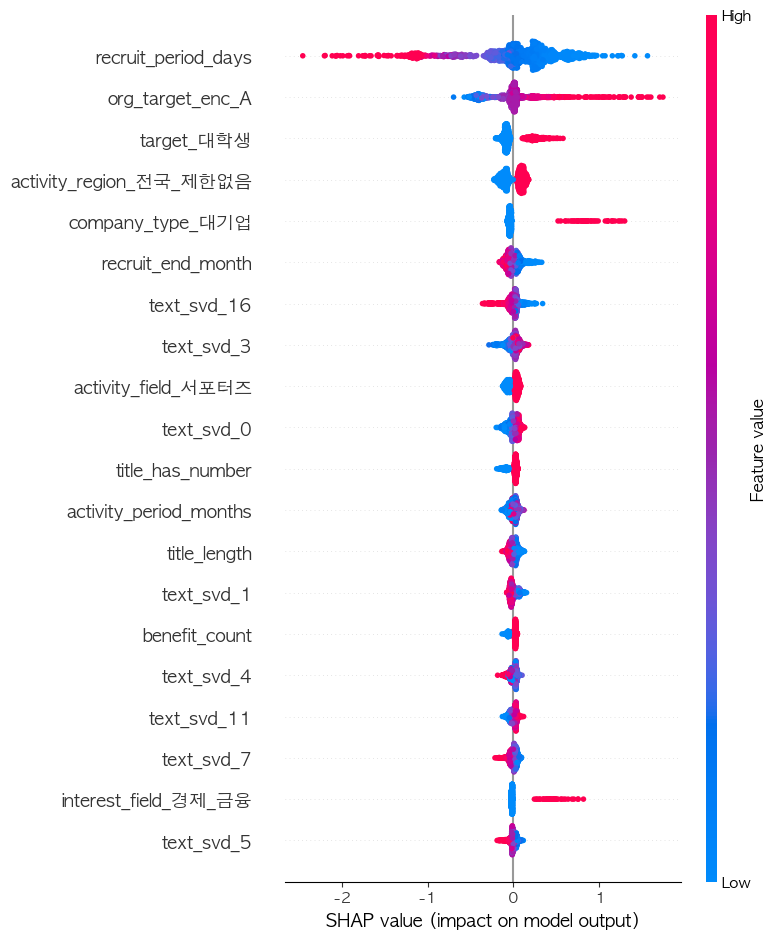

In [ ]:
#한글 깨짐 방지 코드
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. OS별 폰트 파일 경로 직접 지정
# [Windows 사용자]
# font_path = 'C:/Windows/Fonts/malgun.ttf'

# [Mac 사용자 - Mac일 경우 위 줄을 주석처리하고 아래 줄 주석 해제]
font_path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'

# 2. 폰트 적용
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

=== [Target A: daily_views_log1p (조회수)] SHAP 분석 시작 ===


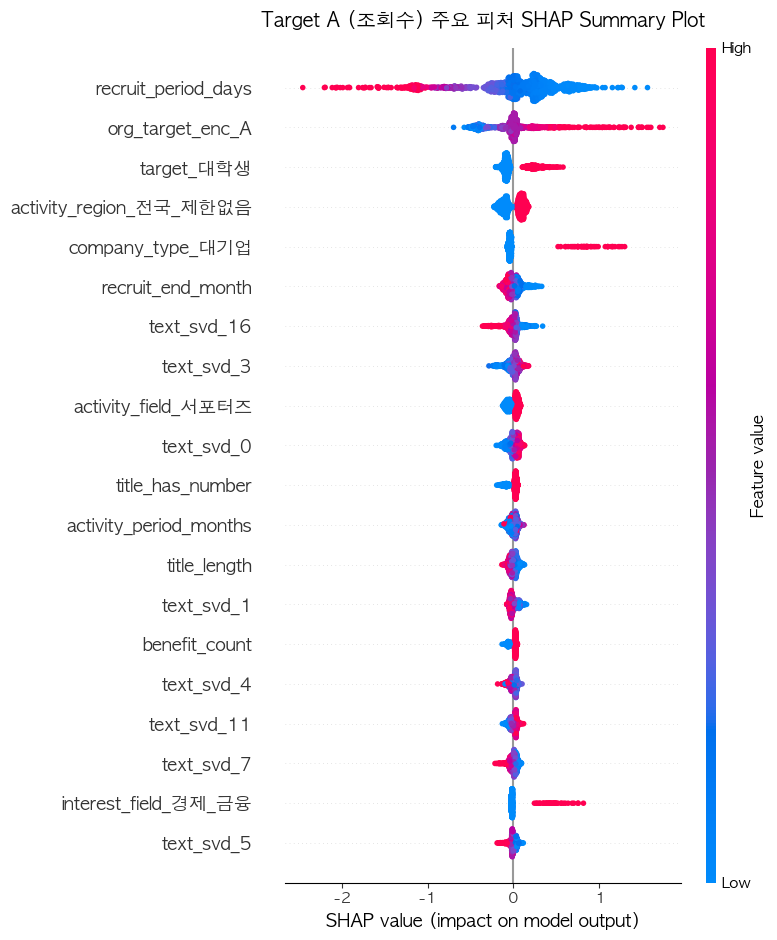


=== [Target B: scrap_rate (%) (전환율)] SHAP 분석 시작 ===


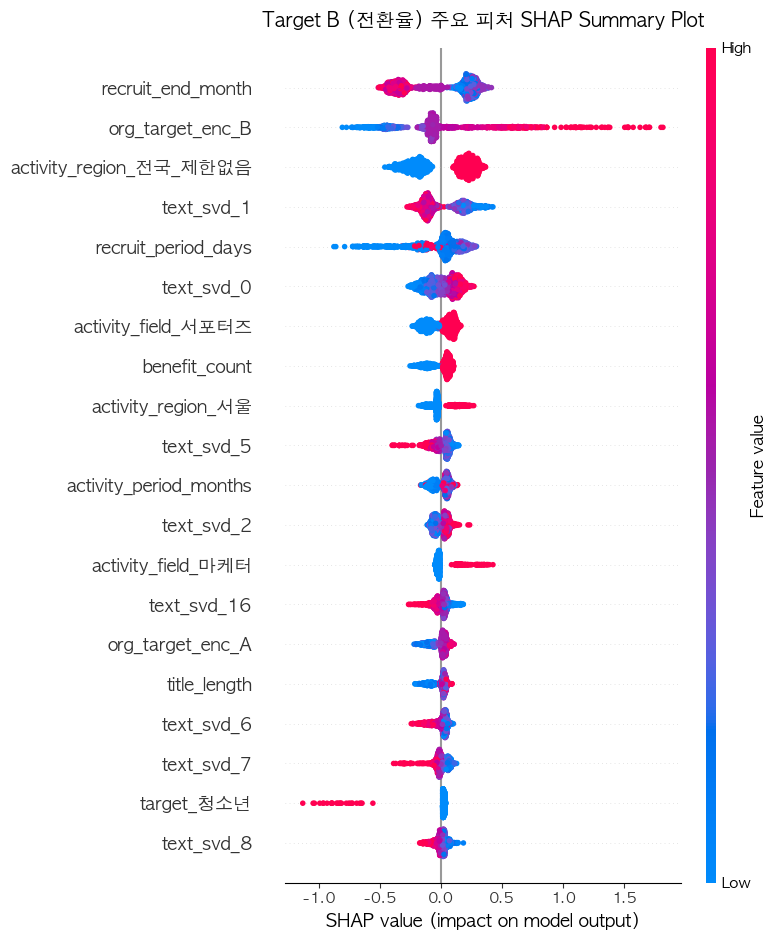

In [23]:
import shap
import matplotlib.pyplot as plt
import koreanize_matplotlib


# ---------------------------------------------------------
# [Target A: 조회수] SHAP 분석
# ---------------------------------------------------------
print("=== [Target A: daily_views_log1p (조회수)] SHAP 분석 시작 ===")
explainer_A = shap.TreeExplainer(grid_lgbm_A.best_estimator_)
shap_values_A = explainer_A.shap_values(X_test_lgbm)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_A, X_test_lgbm, show=False)
plt.title("Target A (조회수) 주요 피처 SHAP Summary Plot", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# [Target B: 스크랩 전환율] SHAP 분석
# ---------------------------------------------------------
print("\n=== [Target B: scrap_rate (%) (전환율)] SHAP 분석 시작 ===")
explainer_B = shap.TreeExplainer(grid_lgbm_B.best_estimator_)
shap_values_B = explainer_B.shap_values(X_test_lgbm)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_B, X_test_lgbm, show=False)
plt.title("Target B (전환율) 주요 피처 SHAP Summary Plot", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd

def get_top20_shap_df(shap_values, feature_df, target_name="Target"):
    # 1. 피처별 평균 절대 SHAP 값 계산 (영향력의 크기)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    
    # 2. DataFrame 생성
    df = pd.DataFrame({
        'Feature': feature_df.columns,
        'SHAP_Importance': mean_abs_shap
    })
    
    # 3. 내림차순 정렬 및 비율(%) 계산
    df = df.sort_values(by='SHAP_Importance', ascending=False).reset_index(drop=True)
    df['Importance_Ratio(%)'] = (df['SHAP_Importance'] / df['SHAP_Importance'].sum()) * 100
    df['Cumulative_Ratio(%)'] = df['Importance_Ratio(%)'].cumsum()
    
    # 4. 상위 20개 추출
    top20_df = df.head(20).copy()
    top20_df.index = range(1, 21) # 순위를 1~20으로 표시
    
    print(f"=== [{target_name}] SHAP Feature Importance Top 20 ===")
    return top20_df

# --- Target A (조회수) 상위 20개 표 ---
df_top20_A = get_top20_shap_df(shap_values_A, X_test_lgbm, "Target A (조회수)")
display(df_top20_A)

# --- Target B (전환율) 상위 20개 표 ---
df_top20_B = get_top20_shap_df(shap_values_B, X_test_lgbm, "Target B (전환율)")
display(df_top20_B)

=== [Target A (조회수)] SHAP Feature Importance Top 20 ===


,Feature,SHAP_Importance,Importance_Ratio(%),Cumulative_Ratio(%)
1,recruit_period_days,0.385724,19.723616,19.723616
2,org_target_enc_A,0.193016,9.869667,29.593283
3,target_대학생,0.127640,6.526733,36.120016
4,activity_region_전국_제한없음,0.104806,5.359156,41.479172
5,company_type_대기업,0.069925,3.575544,45.054716
6,recruit_end_month,0.060191,3.077796,48.132512
7,text_svd_16,0.051293,2.622806,50.755317
8,text_svd_3,0.048423,2.476052,53.231370
9,activity_field_서포터즈,0.048161,2.462639,55.694008
10,text_svd_0,0.043176,2.207749,57.901758


=== [Target B (전환율)] SHAP Feature Importance Top 20 ===


,Feature,SHAP_Importance,Importance_Ratio(%),Cumulative_Ratio(%)
1,recruit_end_month,0.270932,11.235620,11.235620
2,org_target_enc_B,0.264690,10.976769,22.212389
3,activity_region_전국_제한없음,0.222225,9.215737,31.428126
4,text_svd_1,0.150399,6.237071,37.665197
5,recruit_period_days,0.133830,5.549975,43.215172
6,text_svd_0,0.101091,4.192280,47.407453
7,activity_field_서포터즈,0.091705,3.803023,51.210475
8,benefit_count,0.071614,2.969853,54.180328
9,activity_region_서울,0.070963,2.942863,57.123192
10,text_svd_5,0.059630,2.472855,59.596046


# SHAP 총정리
### SHAP 모델을 통해 도출된 값으로 순위를 매기고, 개별값과 전체 비중을 비교해봤을 때 Target A의 경우 상위 6개, Target B는 상위 5개 Features에 대한 상세 설명을 적었습니다.

## SHAP 그래프 결과 분석
- Y축 기준 : 위에 있을수록 중요한 피처(내림차순)
- X축 기준 : 오른쪽일수록 예측값 상승, 왼쪽일수록 예측값 하락
    - 빨간 점(high) : 해당 피처의 수치가 크다/존재한다(1)
    - 파란 점(Low) : 해당 피처의 수치가 작다/없다(0)
ex. target_A에서 recruit_period_days를 보면 빨간점은 왼쪽, 파란점을 오른쪽에 치우쳐진 분포를 볼 수 있다. -> 모집 기간이 짧을수록 예측값이 증가(조회수 증가)하고 길수록 예측값이 하락(조회수 하락)한다.
## SHAP 표 확인 방법
- SHAP_Importance : shap 모델에서 생성된 ‘shap_values’를 절댓값 평균(Mean Absolute)한 값이다. 즉 클수록 중요도가 커진다.
- Importance_Ratio : SHAP_Importance를 백분율로 나타낸것
- Cumulative_Ratio : Importance_Ratio를 누적한 값

### Target A(조회수) 영향력 순위
1. recruit_period_days(0.3857) : 모집기간이 짧을 수록 조회수가 증가하는 반비례 관계를 가지고 있다. 짧고 단기 집중적인 공고인만큼 희소성과 긴급성으로 인해 유저 유입이 늘어나보인다.
2. org_target_enc_A(0.1930) : 기존 평균 조회수가 높았던 기관 공고와의 비례 관계이다.
3. target_대학생(0.1276) : 대학생 대상(빨간점)으로 설정할 수록 비례 관계를 보인다. 플랫폼 메인 유저인 대학생을 설정했는지가 영향을 크게 끼치는 것을 알 수 있다.
4. activity_region_전국_제한없음(0.1048) : 대외활동 특성 상 오프라인 모임이나 접근성이 중요해 수도권 거점 공고가 지방에 비해 유리한 것을 볼 수 있다.
5. company_type_대기업(0.069925) : 빨간 점(대기업)이 독자적인 클러스터로 치우쳐져 형성돼 있다. 대기업이라는 상징성이 유저에게 스펙에 중요하게 작용되어 강한 영향력을 주는 것을 알 수 있다.
#### 총정리 : 조회수를 높이기 위해 대기업 및 인기 기관인 것을 타이틀에 강조하고 수도권 학생 주요 타겟, 모집 기간은 단기로 유저의 행동을 유발하는 것이 유리한 전략이다.

### Target B(전환율) 영향력 순위 - 조회수보다 깊은 관여 활동인 ‘스크랩’을 직접했는지 확인하는 부분
1. recruit_end_month(0.2709) : 파란 점(상반기/연초 마감)이 오른쪽에 위치한것을 보아 신학기/새해에 유저들의 행동력,스펙 욕구가 높아지는 것을 알 수 있다. 반대로 연말 마감은 관심도나 행동력이 비교적 떨어지는 것을 볼 수 있다.
2. org_target_enc_B(0.2647) : Target A와 마찬가지로 과거 전환율이 높은 기관이 영향력을 끼치는 걸 확인할 수 있다. 이 경우 빨간 점이 오른쪽으로 길게 늘어져있는 것을 보아 기관 및 브랜드 신뢰도가 실제 행동(스크랩)까지 이어지는 데 크게 관여하는 것 알 수 있다.
3. activity_region_전국_제한없음(0.2222) : 이것도 마찬가지로 수도권이 더 유리한 양상을 보인다.
4. test_svd_1(0.1504) : 공고 본문 텍스트 패턴이 특정 표현 방식이나 키워드가 있을 수록 유리하게 작용되는 것을 알 수 있다.
5. recruit_period_days(0.1338) : 모집 기간이 Target A처럼 단기 집중이나 호기심은 유발할 수 있지만, 실제 행동까지 이어지는데는 부정적인 영향을 끼치는 것을 알 수 있다. 정보를 검토하고 준비하는데 시간이 부족하여 스크랩을 주저하게 되는 것으로 볼 수 있다.
#### 총정리 : 유저가 실제로 공모할 수 있을지, 충분한 검토가 가능한지 현실적인 관점으로 보았을 때 여유로운 모집기간, 신뢰성 있는 기관 등 충분히 준비해 실제로 활동할 수 있는, 행동력을 이끌어 낼 공고가 유리한 것으로 보인다.
